In [2]:
import numpy as np          # fast math on arrays
import pandas as pd         # DataFrames (tables)
import matplotlib.pyplot as plt  # plotting
import seaborn as sns        # nicer statistical plots

In [6]:
# 1. LOAD THE CSV FILES

results = pd.read_csv("f1/results.csv")
drivers = pd.read_csv("f1/drivers.csv")    # we'll use this for driver names
races   = pd.read_csv("f1/races.csv")      # we'll use this for the year column
 
print("=== Raw results.csv ===")
print(f"Shape: {results.shape}")        # (rows, columns)
print(results.head(3))                  # first 3 rows
print("\nAll columns:", results.columns.tolist())

=== Raw results.csv ===
Shape: (26759, 18)
   resultId  raceId  driverId  constructorId number  grid position  \
0         1      18         1              1     22     1        1   
1         2      18         2              2      3     5        2   
2         3      18         3              3      7     7        3   

  positionText  positionOrder  points  laps         time milliseconds  \
0            1              1    10.0    58  1:34:50.616      5690616   
1            2              2     8.0    58       +5.478      5696094   
2            3              3     6.0    58       +8.163      5698779   

  fastestLap rank fastestLapTime fastestLapSpeed  statusId  
0         39    2       1:27.452         218.300         1  
1         41    3       1:27.739         217.586         1  
2         41    5       1:28.090         216.719         1  

All columns: ['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 

In [13]:
# Re-load results to avoid duplicate-column errors if this cell is re-run
results = pd.read_csv("f1/results.csv")

results = results.merge(
    drivers[['driverId', 'forename', 'surname', 'nationality']],
    on='driverId',
    how='left'
)

# Add the race year from races.csv (useful for filtering)
results = results.merge(
    races[['raceId', 'year', 'name']],
    on='raceId',
    how='left'
)

# Create a full driver name column for readability
results['driver_name'] = results['forename'] + ' ' + results['surname']

print("\n=== After merging ===")
print(results[['driver_name', 'year', 'name', 'grid', 'position', 'points', 'laps']].head(5))


=== After merging ===
         driver_name  year                   name  grid position  points  laps
0     Lewis Hamilton  2008  Australian Grand Prix     1        1    10.0    58
1      Nick Heidfeld  2008  Australian Grand Prix     5        2     8.0    58
2       Nico Rosberg  2008  Australian Grand Prix     7        3     6.0    58
3    Fernando Alonso  2008  Australian Grand Prix    11        4     5.0    58
4  Heikki Kovalainen  2008  Australian Grand Prix     3        5     4.0    58


In [14]:
# 3. SELECT & CLEAN THE COLUMNS WE NEED
# We only keep columns that are meaningful for ML
# The raw dataset has many ID columns and redundant fields we don't need
df = results[[
    'driver_name',
    'nationality',
    'year',
    'grid',           # starting grid position (from qualifying)
    'position',       # final race position
    'points',         # championship points scored (0 to 25)
    'laps',           # number of laps completed
    'milliseconds',   # total race time in ms (NaN if DNF)
    'fastestLapSpeed',# top speed on fastest lap (NaN if not recorded)
    'statusId'        # 1=Finished, other=various retirement reasons
]].copy()  # .copy() prevents a pandas warning about modifying a slice
 
# --- Handle missing values ---
print("\n=== Missing values before cleaning ===")
print(df.isnull().sum())  # count NaNs per column
 
# 'position' has '\N' strings (Ergast's way of saying missing), convert to NaN
# errors='coerce' turns anything that's not a number into NaN silently
df['position'] = pd.to_numeric(df['position'], errors='coerce')
df['milliseconds'] = pd.to_numeric(df['milliseconds'], errors='coerce')
df['fastestLapSpeed'] = pd.to_numeric(df['fastestLapSpeed'], errors='coerce')
 
# grid=0 means the driver started from pit lane — replace with NaN
# (0 is not a real grid position and would confuse algorithms)
df['grid'] = df['grid'].replace(0, np.nan)
 
# Create a binary column: did the driver finish the race?
# statusId == 1 means "Finished" in the Ergast database
df['finished'] = (df['statusId'] == 1).astype(int)  # 1=finished, 0=retired
 
# Create a podium column: did the driver finish in top 3?
# This will be our TARGET for KNN and SVM classification later
df['podium'] = (df['position'] <= 3).astype(int)    # 1=podium, 0=no podium
 
print("\n=== Missing values after cleaning ===")
print(df.isnull().sum())



=== Missing values before cleaning ===
driver_name        0
nationality        0
year               0
grid               0
position           0
points             0
laps               0
milliseconds       0
fastestLapSpeed    0
statusId           0
dtype: int64

=== Missing values after cleaning ===
driver_name            0
nationality            0
year                   0
grid                1638
position           10953
points                 0
laps                   0
milliseconds       19079
fastestLapSpeed    18507
statusId               0
finished               0
podium                 0
dtype: int64


In [15]:
# ============================================================
# 4. FILTER TO A MANAGEABLE, MODERN SUBSET
# ============================================================
 
# We filter to 2010-2024 for two reasons:
#   1. Older races (1950s-1990s) have lots of missing data
#   2. Modern F1 scoring system (points up to 25) starts from 2010
# This gives us ~4,000-5,000 rows — fast on any machine
 
df = df[df['year'] >= 2010].copy()
 
# Drop rows where grid or position is still NaN
# These are usually DNS (Did Not Start) entries — not useful for ML
df = df.dropna(subset=['grid', 'position'])
 
# Reset the index so it goes 0,1,2,... again after filtering
df = df.reset_index(drop=True)
 
print(f"\n=== Final cleaned dataset ===")
print(f"Shape: {df.shape}")
print(f"Years: {df['year'].min()} to {df['year'].max()}")
print(f"Unique drivers: {df['driver_name'].nunique()}")
print(f"Podium entries: {df['podium'].sum()} out of {len(df)} ({df['podium'].mean()*100:.1f}%)")
print(df.head(5))


=== Final cleaned dataset ===
Shape: (5337, 12)
Years: 2010 to 2024
Unique drivers: 79
Podium entries: 915 out of 5337 (17.1%)
        driver_name nationality  year  grid  position  points  laps  \
0   Fernando Alonso     Spanish  2010   3.0       1.0    25.0    49   
1      Felipe Massa   Brazilian  2010   2.0       2.0    18.0    49   
2    Lewis Hamilton     British  2010   4.0       3.0    15.0    49   
3  Sebastian Vettel      German  2010   1.0       4.0    12.0    49   
4      Nico Rosberg      German  2010   5.0       5.0    10.0    49   

   milliseconds  fastestLapSpeed  statusId  finished  podium  
0     5960396.0          191.706         1         1       1  
1     5976495.0          189.392         1         1       1  
2     5983578.0          189.665         1         1       1  
3     5999195.0          188.627         1         1       0  
4     6000609.0          188.599         1         1       0  


In [16]:
# ============================================================
# 5. BASIC STATISTICS
# ============================================================
 
print("\n=== Descriptive Statistics ===")
# Only show the numeric columns we care about
print(df[['grid', 'position', 'points', 'laps', 'fastestLapSpeed']].describe().round(2))
 
print("\n=== Podium class balance ===")
print(df['podium'].value_counts())
# Note: if very imbalanced (e.g. 5000 non-podium vs 500 podium),
# we'll mention this when doing KNN/SVM
 


=== Descriptive Statistics ===
          grid  position   points     laps  fastestLapSpeed
count  5337.00   5337.00  5337.00  5337.00          5302.00
mean     10.71      9.45     5.79    59.24           204.92
std       6.17      5.34     7.46     9.40            20.53
min       1.00      1.00     0.00     1.00           145.27
25%       5.00      5.00     0.00    53.00           192.82
50%      10.00      9.00     2.00    57.00           204.81
75%      16.00     14.00    10.00    68.00           218.50
max      24.00     24.00    50.00    87.00           256.10

=== Podium class balance ===
podium
0    4422
1     915
Name: count, dtype: int64


In [17]:
# ============================================================
# 6. FEATURE MATRIX FOR ML
# ============================================================
 
# Define the 4 features we'll use across ALL algorithms
# We chose these because they're numeric, meaningful, and have few NaNs
 
FEATURES = ['grid', 'laps', 'points', 'fastestLapSpeed']
 
# Drop rows where any of our 4 features is NaN
df_ml = df.dropna(subset=FEATURES).copy()
df_ml = df_ml.reset_index(drop=True)
 
# X = feature matrix (what the algorithms see)
X = df_ml[FEATURES].values   # .values converts DataFrame to numpy array
 
# y = target labels (what we want to predict for KNN/SVM/linear)
y = df_ml['podium'].values
 
print(f"\n=== ML-ready dataset ===")
print(f"X shape: {X.shape}")   # e.g. (3500, 4)
print(f"y shape: {y.shape}")
print(f"Features used: {FEATURES}")
 
# Save the clean dataset to CSV so we can reuse it in every next step
df_ml.to_csv("f1_clean.csv", index=False)
print("\n✓ Saved cleaned dataset to f1_clean.csv")


=== ML-ready dataset ===
X shape: (5302, 4)
y shape: (5302,)
Features used: ['grid', 'laps', 'points', 'fastestLapSpeed']

✓ Saved cleaned dataset to f1_clean.csv


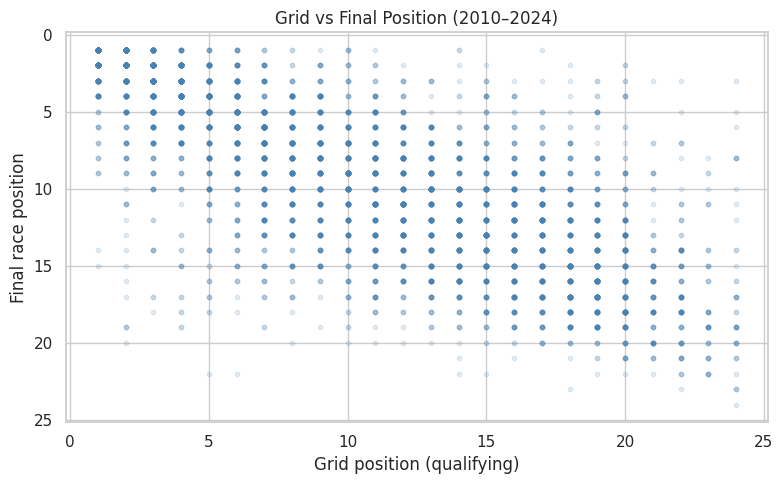

/tmp/ipykernel_11274/267232194.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='podium', y='points', data=df_ml, ax=ax, palette='Set2')
/tmp/ipykernel_11274/267232194.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No podium (0)', 'Podium (1)'])


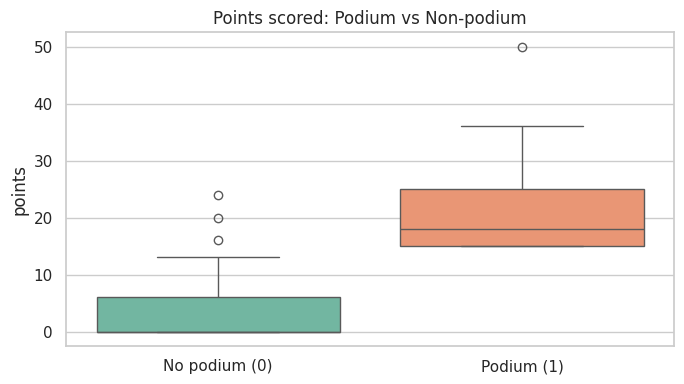

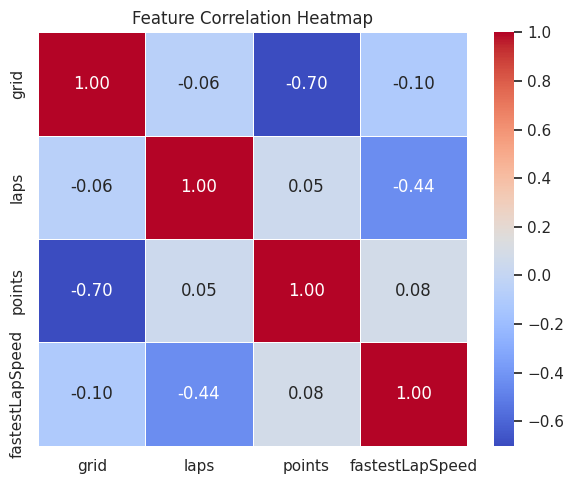

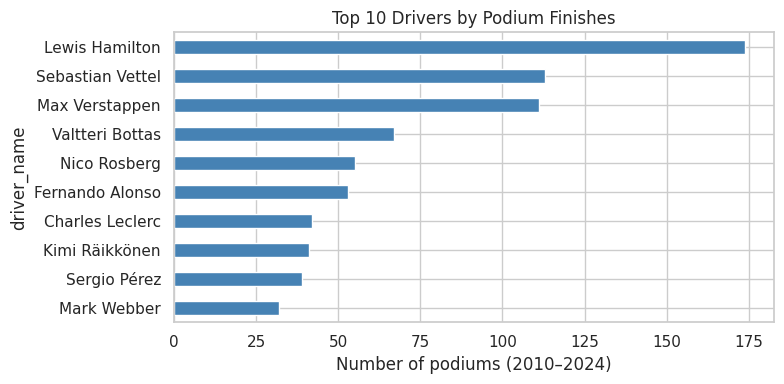


=== Step 0 Complete! ===
Ready for Step 1: K-Means Clustering
X shape: (5302, 4), y shape: (5302,)


In [18]:
# ============================================================
# 7. VISUALIZATIONS
# ============================================================
 
sns.set_theme(style="whitegrid", palette="Set2")
 
# --- Plot 1: Grid position vs Final position ---
# Key F1 question: does qualifying (grid) predict race result?
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_ml['grid'], df_ml['position'],
           alpha=0.15,       # transparency so we can see density
           s=10,             # small dot size
           color='steelblue')
ax.set_xlabel("Grid position (qualifying)")
ax.set_ylabel("Final race position")
ax.set_title("Grid vs Final Position (2010–2024)")
ax.invert_yaxis()   # position 1 should be at the top
plt.tight_layout()
plt.savefig("grid_vs_position.png", dpi=150)
plt.show()
 
# --- Plot 2: Points distribution by podium vs non-podium ---
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(x='podium', y='points', data=df_ml, ax=ax, palette='Set2')
ax.set_xticklabels(['No podium (0)', 'Podium (1)'])
ax.set_title("Points scored: Podium vs Non-podium")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("points_boxplot.png", dpi=150)
plt.show()
 
# --- Plot 3: Correlation heatmap ---
fig, ax = plt.subplots(figsize=(6, 5))
corr = df_ml[FEATURES].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("f1_heatmap.png", dpi=150)
plt.show()
 
# --- Plot 4: Top 10 drivers by podium count ---
top_podium = (df_ml[df_ml['podium'] == 1]
              .groupby('driver_name')
              .size()
              .sort_values(ascending=False)
              .head(10))
 
fig, ax = plt.subplots(figsize=(8, 4))
top_podium.plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_xlabel("Number of podiums (2010–2024)")
ax.set_title("Top 10 Drivers by Podium Finishes")
plt.tight_layout()
plt.savefig("top_drivers.png", dpi=150)
plt.show()
 
print("\n=== Step 0 Complete! ===")
print("Ready for Step 1: K-Means Clustering")
print(f"X shape: {X.shape}, y shape: {y.shape}")